<a href="https://colab.research.google.com/github/RithwikRajSuram/Predictive-Modeling-of-Chronic-Kidney-Disease/blob/main/chronic_kidney_disease_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load the two datasets

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
train = pd.read_csv("kidney_disease_train.csv")
test  = pd.read_csv("kidney_disease_test.csv")

# Select features and target from TRAIN only
X = train[['bp', 'sc']]
y = train['classification']


2. Split TRAIN into train/validation sets (for accuracy)

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)




3. Build Random Forest, train, and get accuracy

In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_valid)
acc = accuracy_score(y_valid, y_pred)

print("Random Forest Accuracy:", acc)


Random Forest Accuracy: 0.8571428571428571


4. Feature importance graph (for PPT slide)

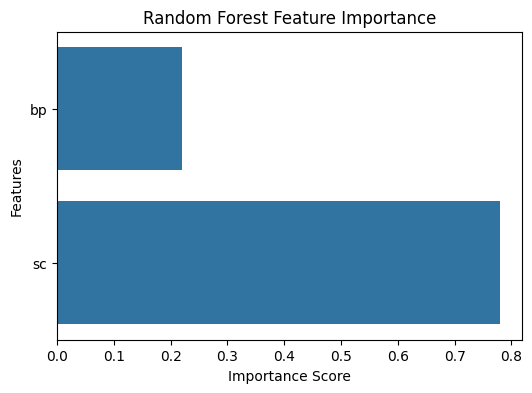

In [4]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


5. (Optional) Predict on the TEST file (no accuracy here)

In [5]:
X_test = test[['bp', 'sc']]
test_pred = rf.predict(X_test)

# Attach predictions to test data (for checking/saving)
test['rf_prediction'] = test_pred
test.head()


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,rf_prediction
0,209,19.0,70.0,1.020,0.0,0.0,NaN,normal,notpresent,notpresent,...,NaN,6900.0,NaN,no,no,no,good,no,no,notckd
1,280,47.0,80.0,NaN,NaN,NaN,NaN,NaN,notpresent,notpresent,...,52,8100.0,5.2,no,no,no,good,no,no,notckd
2,33,60.0,100.0,1.020,2.0,0.0,abnormal,abnormal,notpresent,notpresent,...,29,NaN,NaN,yes,no,no,poor,no,no,ckd
3,210,59.0,100.0,1.015,4.0,2.0,normal,normal,notpresent,notpresent,...,20,9800.0,3.9,yes,yes,yes,good,no,yes,ckd
4,93,73.0,100.0,1.010,3.0,2.0,abnormal,abnormal,present,notpresent,...,30,7000.0,3.2,yes,yes,yes,poor,no,no,ckd
